# Stage 2 — Object Detector (15 kelas) — Pipeline Walkthrough

Sama kayak notebook classification: ini **bukan cara utama training**.
Cara asli tetap lewat CLI:

```bash
python -m src.train_detection --config configs/detection/det_combined.yaml --framework all
```

Notebook ini jalanin ulang logic yang sama pakai fungsi ASLI dari `src/`,
dipecah per-langkah + penjelasan + visualisasi, buat dibaca.

**Prasyarat sebelum cell di bawah bisa jalan beneran:**
1. Dataset stage 2 udah di-build:
   `python scripts/build_combined_dataset.py --task detection --sources gc10=... neu_det=... --out_dir data/combined/detection --negatives_dir data/raw/severstal_clean`
2. `pip install -r requirements.txt` (termasuk `ultralytics`, `torchmetrics`)

Ada 2 framework berbeda buat detector ini (lihat bagian 4-6):
`ultralytics` (YOLOv8/YOLO11/RT-DETR) dan `torchvision` (Faster
R-CNN/RetinaNet). Flag `RUN_TRAINING_*` default `False` di kedua bagian
training, biar buka notebook ini nggak sengaja mancing training beneran
(detection training itu lama).

In [1]:
import os
import sys
from pathlib import Path

if "__vsc_ipynb_file__" in globals():
    # VS Code Jupyter nyuntik path absolut file .ipynb ini ke variabel ini -
    # lebih reliable daripada Path.cwd(), soalnya di VS Code cwd defaultnya
    # ikut FOLDER WORKSPACE yang kebuka, bukan folder tempat file .ipynb ini
    # ada (beda sama Jupyter classic/Lab yang cwd-nya folder si notebook).
    PROJECT_ROOT = Path(__vsc_ipynb_file__).resolve().parents[2]
else:
    # Jupyter classic/Lab: cwd defaultnya folder tempat .ipynb ini berada.
    PROJECT_ROOT = Path.cwd().resolve().parents[1]

if not (PROJECT_ROOT / "requirements.txt").exists():
    raise RuntimeError(
        f"PROJECT_ROOT keliru: {PROJECT_ROOT} (gak ada requirements.txt di situ). "
        "Set manual sebelum lanjut, misal:\n"
        "    PROJECT_ROOT = Path('/Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection')"
    )

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import yaml
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from src.data_loader import get_detection_dataloaders, build_ultralytics_data_yaml, IMAGENET_MEAN, IMAGENET_STD
from src.models.detection import build_model as build_torchvision_model
from src.utils.seed import get_device, set_seed
from src.class_mapping import combined_class_names_for

print(f"Project root: {PROJECT_ROOT}")
print(f"CUDA available: {torch.cuda.is_available()}")


Project root: /Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection
CUDA available: False


## 1. Load config

`det_combined.yaml` = stage 2: union 15 kelas (GC10-DET 10 kelas +
NEU-DET 6 kelas, `inclusion` di-merge) + negative sample dari Severstal
(label kosong = "0 object", udah dihandle otomatis sama loader).

In [2]:
CONFIG_PATH = PROJECT_ROOT / "configs" / "detection" / "det_combined.yaml"
with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

print(yaml.dump(config, sort_keys=False))


experiment_name: steel-defect/detection/combined
dataset:
  name: combined
  root: data/combined/detection
  num_classes: 15
  class_names:
  - inclusion
  - scratches
  - crazing
  - patches
  - pitted_surface
  - rolled-in_scale
  - punching_hole
  - weld_line
  - crescent_gap
  - water_spot
  - oil_spot
  - silk_spot
  - waist_folding
  - crease
  - rolled_pit
img_size: 640
batch_size: 16
epochs: 120
num_workers: 4
seed: 42
frameworks:
  ultralytics:
    architectures:
    - yolov8s
    - yolo11s
    - rtdetr-l
    optimizer: auto
    lr0: 0.01
  torchvision:
    architectures:
    - fasterrcnn_resnet50_fpn_v2
    - retinanet_resnet50_fpn_v2
    optimizer:
      name: sgd
      lr: 0.005
      momentum: 0.9
      weight_decay: 0.0005
output_dir: results/detection/combined



In [3]:
set_seed(config.get("seed", 42))
device = get_device()  # CUDA > MPS (Apple Silicon) > CPU - lihat src/utils/seed.py
class_names = config["dataset"]["class_names"]

print(f"Device: {device}")
print(f"{len(class_names)} kelas: {class_names}")


Device: mps
15 kelas: ['inclusion', 'scratches', 'crazing', 'patches', 'pitted_surface', 'rolled-in_scale', 'punching_hole', 'weld_line', 'crescent_gap', 'water_spot', 'oil_spot', 'silk_spot', 'waist_folding', 'crease', 'rolled_pit']


## 2. Dataset format (YOLO: images/ + labels/)

Data disimpan format YOLO: `images/{train,val,test}/*.jpg` +
`labels/{train,val,test}/*.txt` (`class_id xc yc w h`, normalized 0-1).
Format ini dipakai LANGSUNG oleh kedua framework:

- **ultralytics** (YOLO/RT-DETR) baca langsung lewat `data.yaml` yang
  nunjuk ke folder ini
- **torchvision** (Faster R-CNN/RetinaNet) dibaca lewat
  `YoloDetectionDataset` custom (`src/data_loader.py`) yang convert ke
  format target torchvision (`{boxes: xyxy absolute, labels}`, label
  digeser +1 karena index 0 direservasi buat background)

Gambar negative (dari Severstal, "0 object") punya file label KOSONG —
`YoloDetectionDataset` otomatis balikin `boxes`/`labels` kosong buat kasus
ini, gak ada kode khusus yang perlu peduli soal itu.

In [4]:
data = get_detection_dataloaders(config)
train_ds = data["train_dataset"]

print(f"Train: {len(train_ds)} gambar")
print(f"Val:   {len(data['val_dataset'])} gambar")
print(f"Test:  {len(data['test_dataset'])} gambar")

# cari 1 sample yang beneran ada object-nya (bukan negative) buat divisualisasi
sample_image, sample_target = None, None
for i in range(len(train_ds)):
    image_t, target = train_ds[i]
    if len(target["labels"]) > 0:
        sample_image, sample_target = image_t, target
        break


Train: 3209 gambar
Val:   690 gambar
Test:  691 gambar


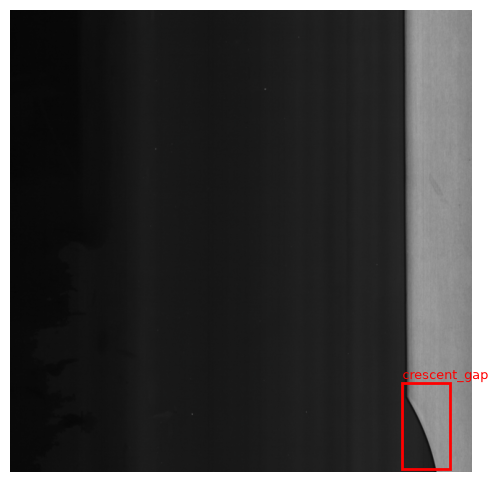

In [5]:
def denormalize(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)


if sample_image is not None:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(denormalize(sample_image).permute(1, 2, 0).numpy())
    for box, label in zip(sample_target["boxes"].tolist(), sample_target["labels"].tolist()):
        x1, y1, x2, y2 = box
        cname = class_names[label - 1]  # -1: geser balik dari background-offset torchvision
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=2))
        ax.text(x1, max(0, y1 - 5), cname, color="red", fontsize=9)
    ax.axis("off")
    plt.show()
else:
    print("Gak ketemu sample dengan object di dataset ini (cek apakah data udah di-build).")


## 3. Class remapping ke 15 kelas kanonik

GC10-DET (10 kelas) dan NEU-DET (6 kelas) punya nama kelas beda, tapi
`inclusion` muncul di keduanya — `scripts/build_combined_dataset.py` udah
remap semuanya ke id kanonik dari `src/class_mapping.py` SEBELUM masuk
`data/combined/detection/`, jadi loader di notebook ini nggak perlu tau
soal remapping sama sekali — dia baca id kelas yang udah final.

In [6]:
print(combined_class_names_for(["gc10", "neu_det"]))


['inclusion', 'scratches', 'crazing', 'patches', 'pitted_surface', 'rolled-in_scale', 'punching_hole', 'weld_line', 'crescent_gap', 'water_spot', 'oil_spot', 'silk_spot', 'waist_folding', 'crease', 'rolled_pit']


## 4. Dua jalur training: ultralytics vs torchvision

| | ultralytics (YOLOv8/YOLO11/RT-DETR) | torchvision (Faster R-CNN/RetinaNet) |
|---|---|---|
| Training loop | Internal di package `ultralytics`, kita panggil `model.train(...)` | Manual (`train_one_epoch_torchvision` di `src/train_detection.py`) |
| Pretrained weights | COCO, auto-download (`yolov8s.pt` dst) | COCO, dari `torchvision.models.detection` |
| mAP | Dihitung otomatis `ultralytics` (`model.val()`) | `torchmetrics.detection.MeanAveragePrecision` |
| MLflow | Auto-logging bawaan `ultralytics` DIMATIKAN sengaja, kita log manual biar formatnya konsisten sama jalur torchvision | Manual dari awal |

## 5. Jalur ultralytics (YOLO/RT-DETR)

In [7]:
from ultralytics import YOLO, RTDETR
from ultralytics import settings as ultralytics_settings
ultralytics_settings.update({"mlflow": False})  # kita log manual, lihat tabel di atas

demo_data_yaml = build_ultralytics_data_yaml(config, PROJECT_ROOT / "results" / "_notebook_demo" / "data.yaml")
print(demo_data_yaml.read_text())


WARNING ⚠️ Ultralytics settings updated to the latest schema. Existing values were preserved where possible. 
View Ultralytics Settings with 'yolo settings' or at '/Users/tiarasabrina/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
path: /Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection/data/combined/detection
train: images/train
val: images/val
test: images/test
names:
  0: inclusion
  1: scratches
  2: crazing
  3: patches
  4: pitted_surface
  5: rolled-in_scale
  6: punching_hole
  7: weld_line
  8: crescent_gap
  9: water_spot
  10: oil_spot
  11: silk_spot
  12: waist_folding
  13: crease
  14: rolled_pit



In [ ]:
RUN_TRAINING_ULTRALYTICS = True  # ubah True kalau mau coba training beneran (lama - lebih baik lewat CLI)
ultra_arch = config["frameworks"]["ultralytics"]["architectures"][0]

if RUN_TRAINING_ULTRALYTICS:
    model_cls = RTDETR if ultra_arch.startswith("rtdetr") else YOLO
    ultra_model = model_cls(f"{ultra_arch}.pt")
    ultra_model.train(data=str(demo_data_yaml), epochs=2, imgsz=config["img_size"], batch=config["batch_size"])
else:
    print(f"RUN_TRAINING_ULTRALYTICS=False, skip. Arsitektur contoh: {ultra_arch}")


Ultralytics 8.4.116 🚀 Python-3.12.9 torch-2.13.0 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection/results/_notebook_demo/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_sc

/Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Overriding model.yaml nc=80 with nc=15

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytic

## 6. Jalur torchvision (Faster R-CNN/RetinaNet)

In [ ]:
tv_arch = config["frameworks"]["torchvision"]["architectures"][0]
tv_model = build_torchvision_model(tv_arch, config["dataset"]["num_classes"], pretrained=True).to(device)

print(f"Arsitektur: {tv_arch}")
print(f"Total parameter: {sum(p.numel() for p in tv_model.parameters()):,}")


In [ ]:
from src.train_detection import train_one_epoch_torchvision, evaluate_torchvision, save_qualitative_predictions

RUN_TRAINING_TORCHVISION = False
DEMO_EPOCHS = 1

if RUN_TRAINING_TORCHVISION:
    tv_optimizer = torch.optim.SGD(tv_model.parameters(), lr=0.005, momentum=0.9, weight_decay=5e-4)
    for epoch in range(1, DEMO_EPOCHS + 1):
        train_loss = train_one_epoch_torchvision(tv_model, data["train_loader"], tv_optimizer, device)
        print(f"epoch {epoch}: train_loss={train_loss:.4f}")
else:
    print("RUN_TRAINING_TORCHVISION=False, skip eksekusi.")


## 7. Evaluasi (mAP) & qualitative check

`evaluate_torchvision()` balikin mAP@0.5, mAP@0.5:0.95, mAP@0.75,
per-class AP (lewat `torchmetrics`). `save_qualitative_predictions()`
gambar bbox prediksi (merah) vs ground truth (hijau) di beberapa sample
test, disimpan sebagai image — ini yang jadi "qualitative check" di
README bagian 5.

In [ ]:
if RUN_TRAINING_TORCHVISION:
    result = evaluate_torchvision(tv_model, data["test_loader"], device, class_names)
    print(result["scalars"])

    qual_path = save_qualitative_predictions(
        tv_model, data["test_dataset"], device, class_names,
        PROJECT_ROOT / "results" / "_notebook_demo",
    )
    print(f"Visualisasi prediksi vs GT: {qual_path}")
else:
    print("Skip - belum ada model yang beneran ke-training di notebook ini.")


## 8. Yang di-log ke MLflow (di run CLI asli)

- **Semua hyperparameter** dari config
- **Per-epoch**: train_loss, val `mAP_50`/`mAP_50_95`/`mAP_75`/`mAR_100` +
  per-class AP
- **Test final**: mAP + per-class AP
- **Best checkpoint** (`best.pt`) berdasarkan `val_mAP_50_95`
- Artifact: qualitative prediction image, (jalur ultralytics) confusion
  matrix/PR-curve bawaan ultralytics, `results.csv`

Detail lengkap: `src/train_detection.py`
(`train_ultralytics_architecture` dan `train_torchvision_architecture`).